In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
%run "../04_dataset_transforms/dataset.ipynb"

Train: 3094
Validation: 774
{'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'minibus': 3, 'savari': 4, 'taxi': 5, 'vanet': 6}
Train dataset size: 3094
Validation dataset size: 774
Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (207, 276)
Label type: <class 'int'>
Original size: (207, 276)
Resized size: (224, 224)
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min: tensor(0.0118)
Max: tensor(1.)
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Label type: <class 'int'>


# 14.1 — Transform , Dataset

In [3]:
train_dataset = TrafficVehicleDataset(
    train_df,
    class_to_idx,
    transform=train_transform
)
val_dataset = TrafficVehicleDataset(
    val_df,
    class_to_idx,
    transform=val_transform
)

In [4]:
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 14.2 — CNN + Learning Rate Scheduler

In [5]:
class SchedulerCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 14.3 — model, loss, optimizer, decive, Scheduler

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model_scheduler = SchedulerCNN(num_classes=7).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_scheduler.parameters(),
    lr=0.001
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

# 14.4 — Training loop 

In [7]:
num_epochs = 10
best_val_accuracy = 0.0
best_epoch = 0

train_losses = []
val_losses = []
val_accuracies = []

learning_rates = []
for epoch in range(num_epochs):

    # Training
    model_scheduler.train()
    running_train_loss = 0.0
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_scheduler(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss /len(train_loader)

    # Validation
    model_scheduler.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_scheduler(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = running_val_loss /len(val_loader)
    val_accuracy = correct / total

    # save results
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Save current learning rate
    current_lr = optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)

    # save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model_scheduler.state_dict(),
            "best_scheduler_model.pt"
        )
        print("  --> Best Scheduler model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f} "
        f"LR: {current_lr:.6f}"
    )

    # Learning rate decay
    scheduler.step()

print()
print("\nBest Epoch:", best_epoch)
print("Best Validation Accuracy:",best_val_accuracy)

  --> Best Scheduler model saved!
Epoch [1/10] Train Loss: 2.1425 Val Loss: 0.9933 Val Accuracy: 0.6421 LR: 0.001000
  --> Best Scheduler model saved!
Epoch [2/10] Train Loss: 0.7006 Val Loss: 0.7979 Val Accuracy: 0.7313 LR: 0.001000
  --> Best Scheduler model saved!
Epoch [3/10] Train Loss: 0.3682 Val Loss: 0.7199 Val Accuracy: 0.7778 LR: 0.001000
  --> Best Scheduler model saved!
Epoch [4/10] Train Loss: 0.1627 Val Loss: 0.5950 Val Accuracy: 0.8140 LR: 0.000100
  --> Best Scheduler model saved!
Epoch [5/10] Train Loss: 0.1116 Val Loss: 0.5926 Val Accuracy: 0.8165 LR: 0.000100
  --> Best Scheduler model saved!
Epoch [6/10] Train Loss: 0.0900 Val Loss: 0.5954 Val Accuracy: 0.8204 LR: 0.000100
  --> Best Scheduler model saved!
Epoch [7/10] Train Loss: 0.0753 Val Loss: 0.5877 Val Accuracy: 0.8217 LR: 0.000010
Epoch [8/10] Train Loss: 0.0719 Val Loss: 0.5840 Val Accuracy: 0.8178 LR: 0.000010
Epoch [9/10] Train Loss: 0.0704 Val Loss: 0.5834 Val Accuracy: 0.8204 LR: 0.000010
Epoch [10/10] T

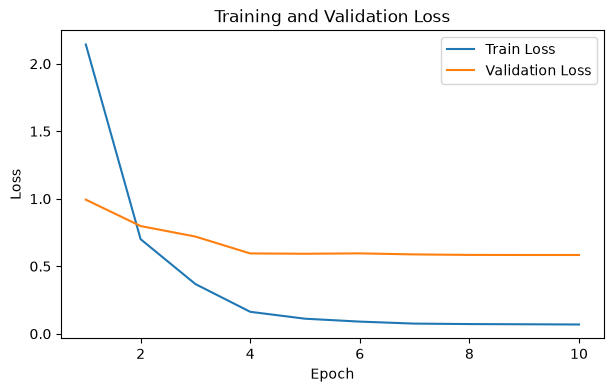

In [8]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

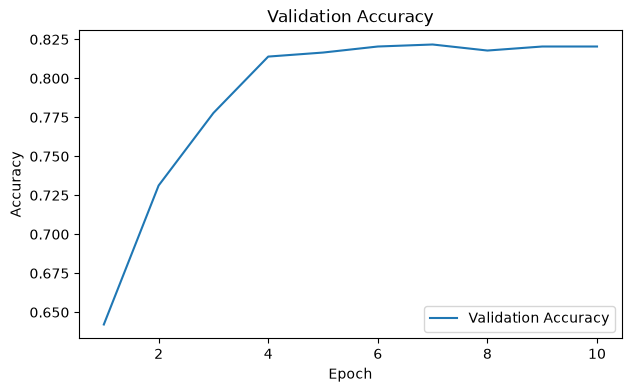

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.show()

# 14.5 — Baseline evaluation on the validation set

In [10]:
model_scheduler.load_state_dict(
    torch.load(
        "best_scheduler_model.pt",
        map_location=device
    )
)
model_dropout = model_scheduler.to(device)
model_dropout.eval()
print("Best LR scheduler Model Loaded")

Best LR scheduler Model Loaded


In [11]:
all_predictions_scheduler = []
all_labels_scheduler  = []
model_scheduler.eval()
with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_dropout(images)
        predictions = outputs.argmax(dim=1)

        all_predictions_scheduler.extend(predictions.cpu().numpy())
        all_labels_scheduler.extend(labels.cpu().numpy())

print("Predictions:", len(all_predictions_scheduler))
print("Labels:", len(all_labels_scheduler))

Predictions: 774
Labels: 774


# 14.6 — Precision , Recall , F1 , confusion_matrix

In [12]:
accuracy = accuracy_score(all_labels_scheduler, all_predictions_scheduler)
precision = precision_score(all_labels_scheduler, all_predictions_scheduler, average="macro")
recall = recall_score(all_labels_scheduler, all_predictions_scheduler, average="macro")
f1 = f1_score(all_labels_scheduler, all_predictions_scheduler, average="macro")
cm = confusion_matrix(all_labels_scheduler, all_predictions_scheduler)

print("Validation Accuracy :", accuracy)
print("Validation Precision:", precision)
print("Validation Recall   :", recall)
print("Validation F1 Score :", f1)
print('confusion_matrix    :\n',cm)

Validation Accuracy : 0.8217054263565892
Validation Precision: 0.8300441841106677
Validation Recall   : 0.8128281527534419
Validation F1 Score : 0.8188804963833304
confusion_matrix    :
 [[ 57   0  12   0   3   0   0]
 [  0  68  11  10   1   3   0]
 [  8   3 161  12   0   1   4]
 [  0   0  15  62   0   1   0]
 [  2   1   3   0  83   0  11]
 [  0   2   5   4   5  81   0]
 [  4   1   5   0  10   1 124]]


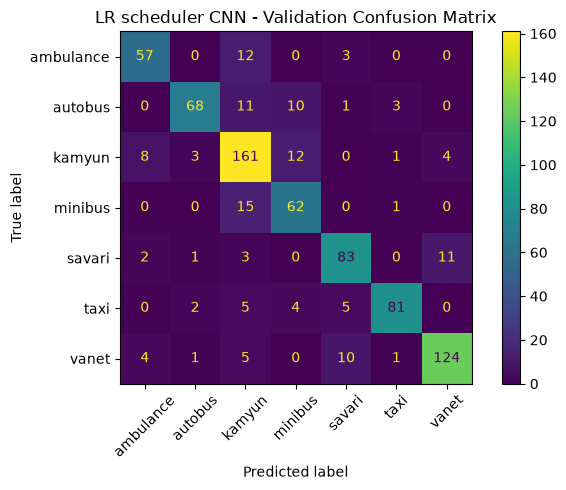

In [13]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("LR scheduler CNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# classification_report

In [14]:
report = classification_report(all_labels_scheduler, all_predictions_scheduler, target_names=classes)
print(report)

              precision    recall  f1-score   support

   ambulance       0.80      0.79      0.80        72
     autobus       0.91      0.73      0.81        93
      kamyun       0.76      0.85      0.80       189
     minibus       0.70      0.79      0.75        78
      savari       0.81      0.83      0.82       100
        taxi       0.93      0.84      0.88        97
       vanet       0.89      0.86      0.87       145

    accuracy                           0.82       774
   macro avg       0.83      0.81      0.82       774
weighted avg       0.83      0.82      0.82       774

